## Phrase-level frequency count of SAR words in PR title, body, and comments

In [ ]:
import pandas as pd
import re
from collections import defaultdict, Counter
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

import sys
directory = '/content/drive/Shared drives/ICS 691G Research Project/Research Project/Data Analysis'
sys.path.append(directory)

import bug_fix_list
import internal_list
import external_list
import functional_list
import code_smell_list

bug_words = bug_fix_list.bug_words
internal_words = internal_list.internal_words
external_words = external_list.external_words
functional_words = functional_list.functional_words
smell_words = code_smell_list.smell_words

Mounted at /content/drive


In [ ]:
print('Starting script.')
pull_request_df = pd.read_parquet("hf://datasets/hao-li/AIDev/pull_request.parquet")
comments_df = pd.read_parquet("hf://datasets/hao-li/AIDev/pr_comments.parquet")
pr_task_type_df = pd.read_parquet("hf://datasets/hao-li/AIDev/pr_task_type.parquet")
print('Finished querying parquets.')
pull_request_df.rename(columns={'id': 'pr_id'}, inplace=True)

Starting script.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Finished querying parquets.


In [ ]:
# need body from pr_comments
combined_df = pull_request_df.merge(
    comments_df[['id', 'body']].add_prefix('comment_'),
    how='left',
    left_on='pr_id',
    right_on='comment_id',
    suffixes=('', '_task')
)
combined_df.drop(columns=['comment_id'])

# only look at refactor
combined_df = combined_df.merge(
    pr_task_type_df[['id', 'type']],
    how='left',
    left_on='pr_id',
    right_on='id'
)
combined_df.rename(columns={'type': 'pr_type'}, inplace=True)
combined_df = combined_df.loc[combined_df['pr_type'].str.contains('refactor', na=False)].copy()


print(f"Length of combined_df: {len(combined_df)}")
# print(combined_df)

Length of combined_df: 2288


In [ ]:
print("Counting SAR phrase occurrences...")

def to_regex_pattern(word):
    return re.escape(word).replace(r'\*', '.*')

for phrase in bug_words:
    pattern = re.compile(to_regex_pattern(phrase), re.IGNORECASE)
    combined_df[phrase] = (
        combined_df['body'].str.contains(pattern, na=False) |
        combined_df['comment_body'].str.contains(pattern, na=False) |
        combined_df['title'].str.contains(pattern, na=False)
    )

for phrase in internal_words:
    pattern = re.compile(to_regex_pattern(phrase), re.IGNORECASE)
    combined_df[phrase] = (
        combined_df['body'].str.contains(pattern, na=False) |
        combined_df['comment_body'].str.contains(pattern, na=False) |
        combined_df['title'].str.contains(pattern, na=False)
    )

for phrase in external_words:
    pattern = re.compile(to_regex_pattern(phrase), re.IGNORECASE)
    combined_df[phrase] = (
        combined_df['body'].str.contains(pattern, na=False) |
        combined_df['comment_body'].str.contains(pattern, na=False) |
        combined_df['title'].str.contains(pattern, na=False)
    )

for phrase in functional_words:
    pattern = re.compile(to_regex_pattern(phrase), re.IGNORECASE)
    combined_df[phrase] = (
        combined_df['body'].str.contains(pattern, na=False) |
        combined_df['comment_body'].str.contains(pattern, na=False) |
        combined_df['title'].str.contains(pattern, na=False)
    )

for phrase in smell_words:
    pattern = re.compile(to_regex_pattern(phrase), re.IGNORECASE)
    combined_df[phrase] = (
        combined_df['body'].str.contains(pattern, na=False) |
        combined_df['comment_body'].str.contains(pattern, na=False) |
        combined_df['title'].str.contains(pattern, na=False)
    )

unique_prs = combined_df.drop_duplicates(subset=['pr_id'])

freq_count = defaultdict(lambda: defaultdict(int))

phrase_lists = [bug_words, internal_words, external_words, functional_words, smell_words]

# To avoid KeyErrors later, prefill counts
agents = unique_prs["agent"].unique()
for agent in agents:
    for list in phrase_lists:
        for phrase in list:
            freq_count[agent][phrase] = 0

for idx, row in unique_prs.iterrows():
    agent = row["agent"]
    for list in phrase_lists:
        found_any = False
        for phrase in list:
            if row[phrase]:
                if not found_any:
                    freq_count[agent][phrase] += 1
                    found_any = True

# Convert dict to DataFrame
summary_df = pd.DataFrame([
    {"agent": agent, **counts}
    for agent, counts in freq_count.items()
])
print(summary_df)

# Save output
output_path = "sar_rq1_phrase_frequency_table.csv"
summary_df.to_csv(output_path)
print(f"Saved table: {output_path}")

Counting SAR phrase occurrences...
          agent  Minor fixes  Get rid of  Additional fixes  Handle  \
0   Claude_Code            0           0                 0       2   
1       Copilot            0           0                 0      74   
2  OpenAI_Codex            0           0                 0      79   
3        Cursor            0           1                 0      12   
4         Devin            0           0                 0      71   

   Decoupling  Reduce complexity  Chang* inheritance  Better encapsulation  \
0           0                  0                   0                     0   
1           7                  1                   1                     1   
2           0                  0                   0                     0   
3           0                  0                   0                     0   
4           0                  1                   1                     0   

   Remov* dependency  ...  UI changes  Avoid code duplication  \
0         

## Research Question Charts & Analysis

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, chisquare
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import matplotlib.pyplot as plt

### RQ 1.2

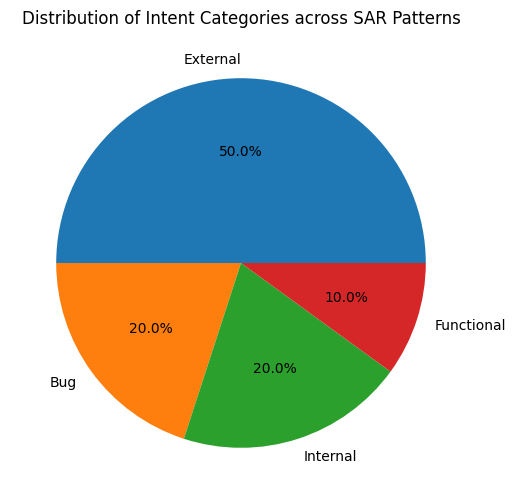

In [ ]:
labels = ['External', 'Bug', 'Internal', 'Functional']
sizes = [50, 20, 20, 10]

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Distribution of Intent Categories across SAR Patterns')
plt.show()

In [ ]:
# Chi-square goodness-of-fit

observed = np.array([50, 20, 20, 10, 0])
expected = np.array([20, 20, 20, 20, 20])  # uniform expectation (can change)

chisq, p = chisquare(f_obs=observed, f_exp=expected)
print("Chi-square goodness-of-fit")
print("Chi-square =", chisq)
print("p-value =", p)

Chi-square goodness-of-fit
Chi-square = 70.0
p-value = 2.2698420336529133e-14


A chi-square goodness-of-fit test is used to determine whether observed categorical data matches an expected distribution.

A chi-square goodness-of-fit test revealed a significant deviation from an even distribution of intent categories, χ²(4, N=100) = 70.00, p < .0001.
This indicates that some intent categories appear far more frequently than others, suggesting non-random usage patterns in SAR documentation.

### RQ 1.3

In [ ]:
# Chi-square test of independence

agent_SAR_count = [
    {"agent": "Claude_Code", "SAR_count": 3, "No_SAR_count": 23},
    {"agent": "Copilot", "SAR_count": 94, "No_SAR_count": 207},
    {"agent": "Cursor", "SAR_count": 17, "No_SAR_count": 94},
    {"agent": "Devin", "SAR_count": 91, "No_SAR_count": 346},
    {"agent": "OpenAI_Codex", "SAR_count": 112, "No_SAR_count": 1301},
]

SAR_count_df = pd.DataFrame(agent_SAR_count)

contingency = pd.crosstab(SAR_count_df["agent"], SAR_count_df["SAR_count"])
chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square test of independence")
print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)


Chi-square test of independence
Chi-square: 20.000000000000004
p-value: 0.22022064660169877
Degrees of freedom: 16


A chi-square test of independence examines whether two categorical variables are related or independent of each other in the data. Here, I tested if the AI agent used and whether a SAR event occurred are independent (unrelated), across five agents and two outcomes (SAR or not).​

A chi-square test of independence found no statistically significant association between agent and SAR occurrence, χ²(16, N=2288) = 20.00, p = .220.
This suggests that SAR documentation frequency does not differ meaningfully across AI agents. There is no compelling evidence that agent choice affects SAR documentation frequency. The pattern of SAR counts is very likely to be due to random variation, not an effect of the specific agent.

### RQ 1.4

In [ ]:
# Chi-square test of independence on agent vocabulary differences
table = summary_df.set_index("agent")
table = table.loc[:, (table.sum(axis=0) > 0)] # Drop columns that are all zeros
chi2, p, dof, expected = chi2_contingency(table)
print("Chi-square:", chi2)
print("p-value:", p)
print("degrees of freedom:", dof)

Chi-square: 126.2137271366511
p-value: 2.3144871292722765e-05
degrees of freedom: 68


A chi-square test of independence measures whether two categorical variables (AI agent and SAR phrase usage) are related or independent.

A chi-square test of independence revealed a statistically significant association between AI agent and SAR phrase usage, χ²(68, N=317) = 126.21, p < .0001.
This indicates that the agents exhibit distinct vocabulary preferences when documenting refactoring activities. Agents do not use SAR phrases in the same way as each other.